# Ayan's Emotion Detector — Transfer Learning with PyTorch

**Model:** ResNet18 pre-trained on ImageNet, fine-tuned on FER2013  
**Task:** 7-class facial expression recognition: Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral  
**Goal:** Real-time detection via Flask + OpenCV

---
### Dataset Setup
Download FER2013 from Kaggle:
```
kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
```
Or manually from: https://www.kaggle.com/datasets/msambare/fer2013

Extract so your folder looks like:
```
data/
  train/
    angry/  disgust/  fear/  happy/  sad/  surprise/  neutral/
  test/
    angry/  disgust/  fear/  happy/  sad/  surprise/  neutral/
```

In [2]:
# Install dependencies (run once)
# !pip install torch torchvision matplotlib seaborn scikit-learn tqdm

In [3]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from model import EmotionClassifier, EMOTIONS

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Emotions: {EMOTIONS}')

Using device: cpu
Emotions: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']


## 1. Data Loading & Augmentation

In [5]:
DATA_DIR  = 'data'          # change if your path differs
BATCH_SIZE = 64
IMG_SIZE   = 224

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=val_transforms)

# Weighted sampler to handle class imbalance (FER2013 is imbalanced)
class_counts = np.array([len(os.listdir(os.path.join(DATA_DIR, 'train', c)))
                         for c in train_ds.classes])
weights      = 1.0 / class_counts
sample_weights = weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} samples | Val: {len(val_ds)} samples')
print(f'Classes: {train_ds.classes}')

Train: 28709 samples | Val: 7178 samples
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


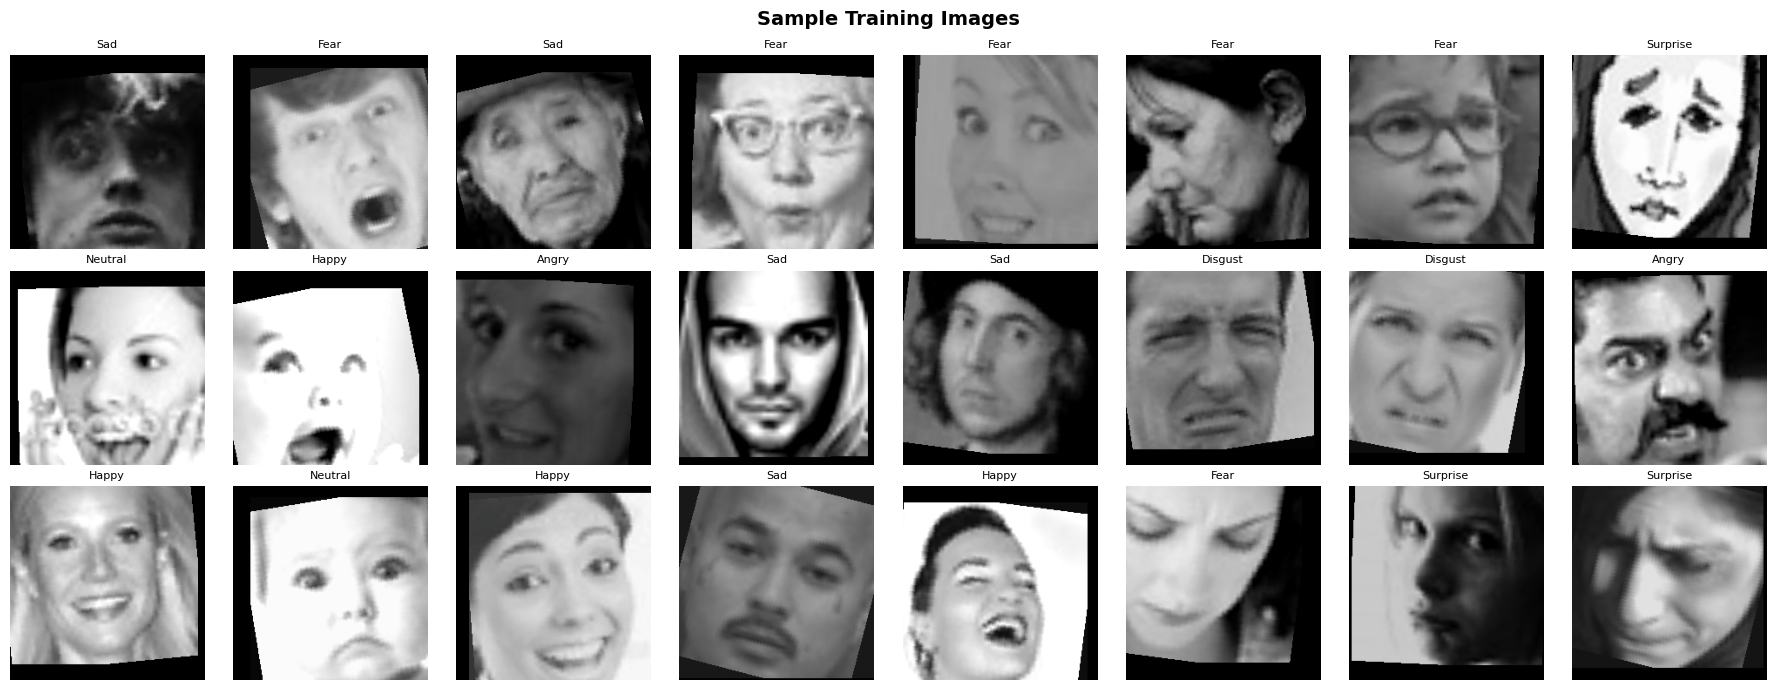

In [6]:
# Visualise a batch of training images
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
for i, ax in enumerate(axes.flatten()):
    if i >= len(imgs): break
    img = denorm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(EMOTIONS[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Build the Model (ResNet18 Transfer Learning)

In [8]:
model = EmotionClassifier(pretrained=True, freeze_backbone=False).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:,}')
print(f'Trainable params: {trainable:,}')
print('\nBackbone layers:')
for i, layer in enumerate(model.backbone):
    print(f'  [{i}] {layer.__class__.__name__}')
print('\nClassifier head:')
print(model.classifier)

Total params:     11,309,639
Trainable params: 11,309,639

Backbone layers:
  [0] Conv2d
  [1] BatchNorm2d
  [2] ReLU
  [3] MaxPool2d
  [4] Sequential
  [5] Sequential
  [6] Sequential
  [7] Sequential
  [8] AdaptiveAvgPool2d

Classifier head:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=7, bias=True)
)


## 3. Training

In [ ]:
EPOCHS    = 30
LR        = 3e-4
LR_MIN    = 1e-6

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc   = 0.0
best_weights = copy.deepcopy(model.state_dict())

def run_epoch(loader, training=True):
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad if training else torch.no_grad
    with ctx():
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            preds  = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
    return total_loss / total, correct / total

print('Training started...')
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc*100:.2f}% | '
          f'{elapsed:.1f}s')

    if vl_acc > best_acc:
        best_acc     = vl_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, 'emotion_model.pth')
        print(f'  ✓ Best model saved! Val Acc: {best_acc*100:.2f}%')

print(f'\nTraining complete. Best Val Acc: {best_acc*100:.2f}%')

Training started...


Epoch 01/30 | Train Loss: 1.4131 Acc: 52.38% | Val Loss: 1.2772 Acc: 59.18% | 1796.6s
  ✓ Best model saved! Val Acc: 59.18%


Epoch 02/30 | Train Loss: 1.2090 Acc: 63.67% | Val Loss: 1.2171 Acc: 62.69% | 1917.0s
  ✓ Best model saved! Val Acc: 62.69%


Epoch 03/30 | Train Loss: 1.1353 Acc: 67.29% | Val Loss: 1.1816 Acc: 64.63% | 1740.6s
  ✓ Best model saved! Val Acc: 64.63%


Epoch 04/30 | Train Loss: 1.0909 Acc: 69.84% | Val Loss: 1.2203 Acc: 63.68% | 3122.2s


Epoch 05/30 | Train Loss: 1.0510 Acc: 71.47% | Val Loss: 1.1793 Acc: 64.03% | 2544.8s


 57%|███████████████████████▍                 | 257/449 [23:51<12:39,  3.96s/it]

## 4. Training Curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
ax1.set_title('Loss Curves', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
ax2.set_title('Accuracy Curves', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training Metrics — ResNet18 on FER2013', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation — Confusion Matrix & Classification Report

In [ ]:
from model import load_model

model, _ = load_model('emotion_model.pth', DEVICE)

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('\n' + '='*60)
print('Classification Report')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontweight='bold')
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax2)
ax2.set_title('Confusion Matrix (% per class)', fontweight='bold')
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Visualise Predictions on Real Validation Samples

In [ ]:
import random

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
model.eval()

sample_indices = random.sample(range(len(val_ds)), 24)
with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        img_t, true_label = val_ds[idx]
        logits = model(img_t.unsqueeze(0).to(DEVICE))
        probs  = torch.softmax(logits, 1)
        conf, pred = probs.max(1)

        ax = axes[i // 8][i % 8]
        img = denorm(img_t).permute(1, 2, 0).numpy()
        ax.imshow(img)
        color = 'green' if pred.item() == true_label else 'red'
        ax.set_title(f'{EMOTIONS[pred.item()]}\n{conf.item()*100:.0f}%',
                     fontsize=7, color=color, fontweight='bold')
        ax.axis('off')

plt.suptitle('Predictions on Validation Set  (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Launch the Flask App

Model trained and saved as `emotion_model.pth`!  
Now run the Flask app from a terminal:

```bash
python app.py
```

Then open **http://localhost:5000** in your browser 🚀

In [ ]:
# Optional: launch from notebook (blocks the cell)
# import subprocess
# subprocess.Popen(['python', 'app.py'])
print('Run: python app.py   then open http://localhost:5000')